In [70]:
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

In [71]:
n = 6
p = 0.5
G = nx.erdos_renyi_graph(n, p)
A = nx.to_numpy_array(G)
#first half of the nodes
group_1 = list(range(n // 2))
group_2 = list(range(n // 2, n))

#diagonal matrix of values between 1 and 3
D = np.diag(np.random.uniform(2, 3, n))
#diagonal matrix of values between 0 and 1
B = np.diag(np.random.uniform(0, 1, n))
#times that we switch our hybrid model 
T = [1, 10, 45, 100, 300]
#initial state
x0 = np.random.uniform(0, .3, n)
print(D)
print(B)
print(T)
# print(group_1)
# print(group_2)
# print(A)


[[2.33748985 0.         0.         0.         0.         0.        ]
 [0.         2.2185419  0.         0.         0.         0.        ]
 [0.         0.         2.45733078 0.         0.         0.        ]
 [0.         0.         0.         2.504629   0.         0.        ]
 [0.         0.         0.         0.         2.47641909 0.        ]
 [0.         0.         0.         0.         0.         2.31304108]]
[[0.92543906 0.         0.         0.         0.         0.        ]
 [0.         0.37938495 0.         0.         0.         0.        ]
 [0.         0.         0.78555208 0.         0.         0.        ]
 [0.         0.         0.         0.52479373 0.         0.        ]
 [0.         0.         0.         0.         0.56103249 0.        ]
 [0.         0.         0.         0.         0.         0.97731464]]
[1, 10, 45, 100, 300]


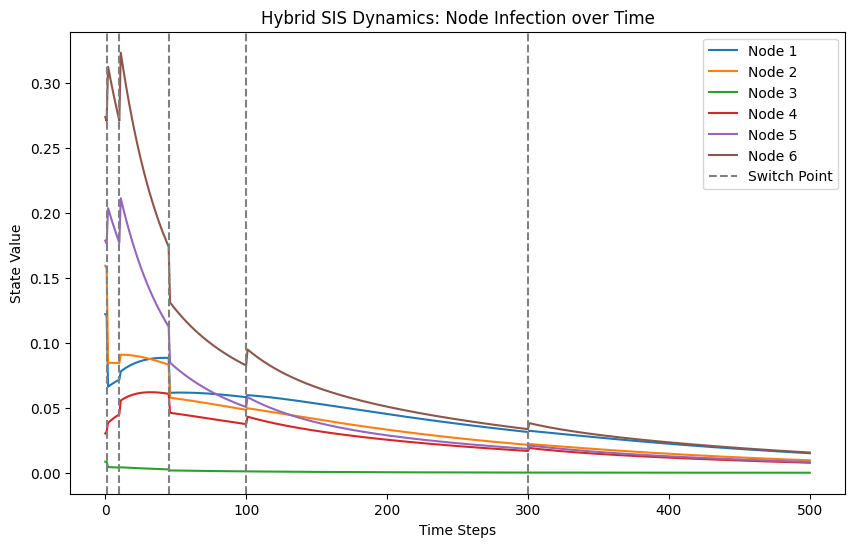

In [72]:
#change beta and gamma at switching 
def f_switching(x_k, D, B, group_1, group_2):
    a_r_1 = np.random.uniform(0.5, 1.5)
    a_r_2 = np.random.uniform(0.5, 1.5)
    x_k = x_k.copy()
    D = D.copy()
    B = B.copy()
    x_k[group_1] = a_r_1 * x_k[group_1]
    x_k[group_2] = a_r_2 * x_k[group_2]
    #also scale respective rows of D and B for each group
    D[group_1, group_1] = a_r_1 * D[group_1, group_1]
    D[group_2, group_2] = a_r_2 * D[group_2, group_2]
    B[group_1, group_1] = a_r_1 * B[group_1, group_1]
    B[group_2, group_2] = a_r_2 * B[group_2, group_2]
    return x_k, D, B

def simulate_dynamics(h, x, A, D, B, group_1, group_2, T, total_time, f_switching):
    n = A.shape[0]
    x_k = x.copy()
    #store the state information
    states = []
    states.append(x_k.copy())
    for k in range(total_time):
        if k in T:
            
            # print("scaling factors: ", a_r_1, a_r_2)
            # print("before switch: ", x_k)
            x_k, D, B = f_switching(x_k, D, B, group_1, group_2)
            #clip x_k to be between 0 and 1
            x_k = np.clip(x_k, 0, 1)
            # print("after switch: ", x_k)

        x_k_1 = h *( -D @ x_k + (np.eye(n) - np.diag(x_k))@B@A@x_k) + x_k
        #clip x_k_1 to be between 0 and 1
        x_k_1 = np.clip(x_k_1, 0, 1)
        x_k = x_k_1
        states.append(x_k)
    return states

total_time = 500
h = 0.01
states = simulate_dynamics(h, x0, A, D, B, group_1, group_2, T, total_time, f_switching)
#plot the states over time
states = np.array(states)
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(states[:, i], label=f'Node {i+1}')
#also plot vertical lines when we switch the hybrid model
for t in T:
    plt.axvline(x=t, color='gray', linestyle='--', label='Switch Point' if t == T[0] else "")   
plt.xlabel('Time Steps')
plt.ylabel('State Value')
plt.title('Hybrid SIS Dynamics: Node Infection over Time')
plt.legend()
plt.show()

#how does the network topology affect when we should update ? 
#being careful on how we do the updates, like for example if we update every day ppl lose interest, get annoyed etc
#how does the product chAnge during update times and in between 
#for next week: come up with 3 products car, phone or something else, sfotware service, and think of a model that matches for each separate product
#make plots and convince phil and jitesh that it makes more sense 
#check ians paper for software parameters
#if we have time look at graph structures for each product 
#how does chaning parameters change the behavior 

Model Parameters:
* $\delta$ = disinterest rate, or the rate at which people stop using the product 
* $\beta$ = adoption rate, or the rate at which people start using the product


## EV Demand Proposed Model

### Factors that Cause Demand to Spread: 
* Visibility: If people see an EV in their community.
* Accessibility: If there is a charging station nearby and convenient.
* Trust: Trust in battery technology.
* Variety: Availability of different models, instead of just one or two models.

### Graph Type: Hub and Spoke
* **Reason:** EV adoption is a highly geographic element. People are more likely to adopt an EV if they see one in their neighborhood or if a charging station is nearby. The network should not be homogeneous like an Erdős–Rényi (ER) graph, although an ER graph might be suitable for software-only diffusion.

### Parameters:
* $\delta$ should be large (high disinterest/dropout rate)
* $\beta$ should scale when a new model comes out


Sources:
* https://generation180.org/resource/your-influence-matters-peer-influence-and-electric-vehicle-adoption/
* https://jtlu.org/index.php/jtlu/article/view/2113
* https://www.researchgate.net/publication/398712161_Modelling_the_'S_curve'_transition_dynamics_in_EV_adoption

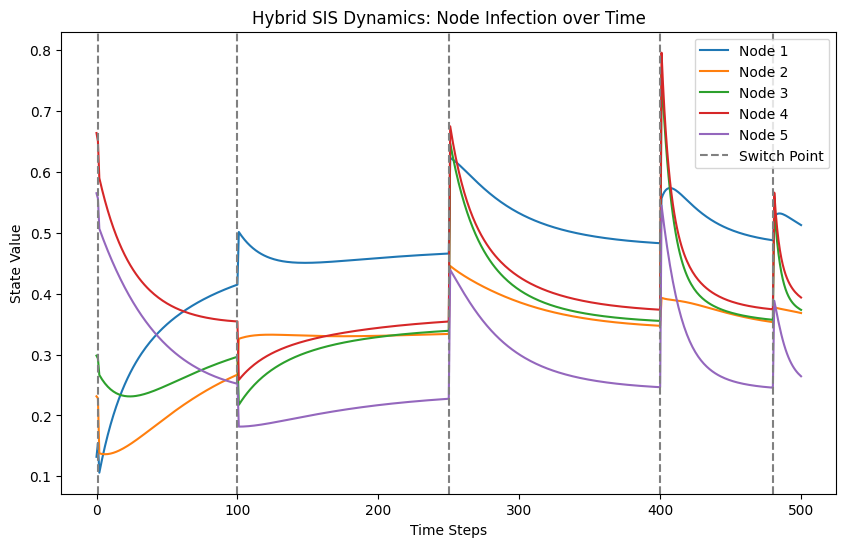

In [73]:
#define an appropriate switching function
def f_EV(x_k, D, B, group_1, group_2):
    #for electric vehicles maybe we want to increase the rate of adoption for group 1 and decrease for group 2
    a_r_1 = np.random.uniform(0.5, 2.0)  # increase adoption rate for group 1
    a_r_2 = np.random.uniform(0.5, 3.0)  # decrease adoption rate for group 2
    x_k = x_k.copy()
    D = D.copy()
    B = B.copy()
    x_k[group_1] = a_r_1 * x_k[group_1]
    x_k[group_2] = a_r_2 * x_k[group_2]
    #also scale respective rows of D and B for each group
    D[group_1, group_1] = a_r_1 * D[group_1, group_1]
    D[group_2, group_2] = a_r_2 * D[group_2, group_2]
    B[group_1, group_1] = a_r_1 * B[group_1, group_1]
    B[group_2, group_2] = a_r_2 * B[group_2, group_2]
    return x_k, D, B
n = 5
G = nx.barabasi_albert_graph(n=n, m=1, seed=42)
#EV simulation parameters
A = nx.to_numpy_array(G)
group_1 = list(range(n // 2))
group_2 = list(range(n // 2, n))
T = [1, 100, 250, 400, 480]
D = np.diag(np.random.uniform(2, 3, n))
#diagonal matrix of values between 0 and 1
B = np.diag(np.random.uniform(2, 3, n))
x0 = np.random.uniform(0, 0.7, n)
total_time = 500
h = 0.01

#Simulate dynamics
states = simulate_dynamics(h, x0, A, D, B, group_1, group_2, T, total_time, f_EV)
states = np.array(states)

#plot the states over time
plt.figure(figsize=(10, 6))
for i in range(n):
    plt.plot(states[:, i], label=f'Node {i+1}')
#also plot vertical lines when we switch the hybrid model
for t in T:
    plt.axvline(x=t, color='gray', linestyle='--', label='Switch Point' if t == T[0] else "")   
plt.xlabel('Time Steps')
plt.ylabel('State Value')
plt.title('Hybrid SIS Dynamics: Node Infection over Time')
plt.legend()
plt.show()


## Streaming Services Proposed Demand Model 



### Factors that cause Spread: 
* New shows or big hit content (releasing new content is an update in the language of our model )
* price tiers change who subscribes 

### Parameters:
* $\beta$ Should have some sort of relation with the number of updates or how frequently you update. Too many updates and people lose shows they like and become disinterested, also the quality of the content is probably not as good 
* $\delta$ kind of the opposite as the trend described above 




Sources:
* https://matrixbcg.com/blogs/target-market/netflix


## Generative AI Model Proposed Demand Model

### Factors that cause Demand to spread or Increase:
* the more features a model has, the more popular it will be. 
* In this case, you want as many updates as possible, assuming the updates are actually good 

### Parameters:
* $\beta$ should be a function of the frequency of updates. the more updates the higher $\beta$ is
* $\delta$ depends on the quality of the updates. IF we assume that updates are always high quality ones, then it should be an inverse relationship to $\beta$. 
* $\delta$ also increases with the number of hallucinations the model has, and how quickly it takes for the user to reach the limit


